In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [3]:
datapath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-05_09-28-56\slap2\dynamic_data\dendriticVoltageExtraction\dendriticVoltageSummary-260422-111336.mat"
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures"

In [4]:
vs = VoltageSummary(datapath)

In [12]:
vs.valid_trials

[[1], [1]]

In [10]:
dmd1_traces = vs.get_roi_traces(dmd=1,trial=1)
dmd2_traces = vs.get_roi_traces(dmd=2,trial=1)

In [11]:
dmd1_traces.shape

(26, 14)

In [6]:
im_rate = dmd1_traces.shape[0]/1800

<IPython.core.display.Javascript object>


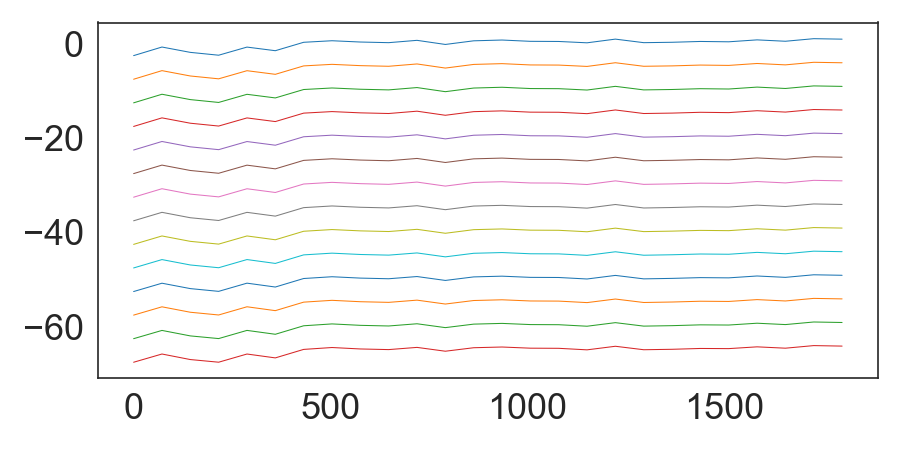

In [7]:
fig,ax=plt.subplots(figsize=(6,3))

offset = 5
time = np.linspace(0,dmd1_traces.shape[0]/im_rate,dmd1_traces.shape[0])

for roi in range(dmd1_traces.shape[1]):
    
    trace = dmd1_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    ax.plot(time[::],-trace[::]-offset*roi,lw=0.5)
    
    
fig.tight_layout()

In [ ]:
fig,ax=plt.subplots(figsize=(6,3))

offset = 5
time = np.linspace(0,dmd2_traces.shape[0]/im_rate,dmd2_traces.shape[0])

for roi in range(dmd2_traces.shape[1])[:]:
    
    trace = dmd2_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    ax.plot(time[::],-trace[::]-offset*roi,lw=0.5)

fig.tight_layout()

In [ ]:
rois_of_interest = [0,4,10,15]
cl,cmap,cp = PNW_cmap.get_PNW_cmap('Bay',n_colors=len(rois_of_interest))
fig,ax=plt.subplots(figsize=(6,3))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

offset = 5
time = np.linspace(0,dmd2_traces.shape[0]/im_rate,dmd2_traces.shape[0])
window = (600000,900000)
for i,roi in enumerate(rois_of_interest):
    
    trace = dmd2_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    rolling = pd.DataFrame(trace).rolling(20,min_periods=1).mean()
    
    ax.plot(time[window[0]:window[1]]-time[window[0]],
            -rolling[window[0]:window[1]]-offset*i,
            lw=1,
           color=cp[i])
yticks = -np.arange(len(rois_of_interest)) * offset
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(len(rois_of_interest)))   
ax.set_xlabel('Time (s)')
ax.set_ylabel('Dendrite ROI')

for spine in ['top','bottom','left','right']:
    ax.spines[spine].set_linewidth(2)
ax.set_title('Dendritic voltage imaging')
fig.tight_layout()